### Clustering Method
**Clustering method** is a widely applied method in many domains like customer and image segmentation, image recognition, bioinformatics, and anomaly detection, all to group data into clusters in terms of similarity. 
**Clustering methods** have a double-sided nature: 
- as a machine learning technique aimed at discovering knowledge underneath unlabeled data (unsupervised learning), 
- as a descriptive data analysis tool for uncovering hidden patterns in data.

### Elbow method 
**Elbow method** is a technique used to find the optimal number of clusters (K) in k-means clustering, by identifying the “elbow” point on a graph of k-values and their corresponding within-cluster sum of squares (WCSS) values.

### Silhouette analysis 
**Silhouette method** can be used to study the separation distance between the resulting clusters. 
The silhouette plot displays a measure of how close each point in one cluster is to points in the neighboring clusters and thus provides a way to assess parameters like number of clusters visually. 

## 1. Import data & libraries

In [ ]:
# import neccessary libraries

import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # features scaling
from sklearn.cluster import KMeans # elbow method
from sklearn.metrics import silhouette_score # silhouette method
from sklearn.decomposition import PCA # vizualize

# display setup 
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('pastel')

In [ ]:
# import data
df = pd.read_csv('../data/clean/clean_data.csv')

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Dt_year,Dt_month,Dt_day,Children,IsParent,MntTotal,Age,NumPurchaseTotal,log_Age,log_Recency,log_Income,log_Children,log_MntTotal,log_MntWines,log_MntFruits,log_MntMeatProducts,log_MntFishProducts,log_MntSweetProducts,log_MntGoldProds,log_NumPurchaseTotal
0,5524,1957,Graduation,Single,58138.000,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,2012,9,4,0,0,1617,68,25,4.234,4.078,10.971,0.000,7.389,6.455,4.489,6.304,5.153,4.489,4.489,3.258
1,2174,1954,Graduation,Single,46344.000,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,2014,3,8,2,1,27,71,6,4.277,3.664,10.744,1.099,3.332,2.485,0.693,1.946,1.099,0.693,1.946,1.946
2,4141,1965,Graduation,In a relationship,71613.000,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,2013,8,21,0,0,776,60,21,4.111,3.296,11.179,0.000,6.655,6.057,3.912,4.852,4.718,3.091,3.761,3.091
3,6182,1984,Graduation,In a relationship,26646.000,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,2014,2,10,1,1,53,41,8,3.738,3.296,10.190,0.693,3.989,2.485,1.609,3.045,2.398,1.386,1.792,2.197
4,5324,1981,PhD,In a relationship,58293.000,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,2014,1,19,1,1,422,44,19,3.807,4.554,10.973,0.693,6.047,5.159,3.784,4.779,3.850,3.332,2.773,2.996


## 2. Data Preparation

### 2.1. Features for clustering

In [ ]:
# encode categorical variable
education_mapping = {
    'Basic': 1,
    '2n Cycle': 2,
    'Graduation': 3,
    'Master': 4,
    'PhD': 5
}

In [ ]:
df['Education_Encoded'] = df['Education'].map(education_mapping)

In [ ]:
# check after encoding
print("Education Encoding:")
print(df[['Education', 'Education_Encoded']].drop_duplicates().sort_values('Education_Encoded'))
print(f"\nMissing values after encoding: {df['Education_Encoded'].isna().sum()}")

Education Encoding:
     Education  Education_Encoded
10       Basic                  1
18    2n Cycle                  2
0   Graduation                  3
5       Master                  4
4          PhD                  5

Missing values after encoding: 0


In [ ]:
features_for_clustering = [
    # Demographics
    'Income',
    'Children',
    'Education_Encoded',
    
    # Spending behavior
    'log_MntWines',
    'log_MntFruits', 
    'log_MntMeatProducts',
    'log_MntFishProducts',
    'log_MntSweetProducts',
    'log_MntGoldProds',
    
    # Channel behavior
    'NumWebPurchases',
    'NumCatalogPurchases', 
    'NumStorePurchases',
    'NumDealsPurchases',
    'NumWebVisitsMonth',

    # Recency
    'Recency'
]

In [ ]:
# define the inputs we will use for our K-means clustering algorithm
X = df[features_for_clustering].copy()

### 2.2.  Features Scaling

In [ ]:
# initialise the scaler
scaler = StandardScaler()

# scale data
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
# transform data
X_scaled = scaler.transform(X)

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
print("\nAfter scaling:")
print(X_scaled_df.head())
print("\nMean:", X_scaled_df.mean())
print("Std:", X_scaled_df.std()) 


After scaling:
   Income  Children  Education_Encoded  log_MntWines  log_MntFruits  \
0   0.298    -1.267             -0.455         0.982          1.429   
1  -0.262     1.402             -0.455        -1.220         -0.988   
2   0.938    -1.267             -0.455         0.761          1.062   
3  -1.196     0.067             -0.455        -1.220         -0.405   
4   0.305     0.067              1.538         0.263          0.981   

   log_MntMeatProducts  log_MntFishProducts  log_MntSweetProducts  \
0                1.400                1.576                 1.409   
1               -1.402               -0.870                -0.975   
2                0.466                1.314                 0.531   
3               -0.696               -0.086                -0.540   
4                0.419                0.790                 0.682   

   log_MntGoldProds  NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
0             1.068            1.496                2.686     

## 3. Determine the number of clusters

### 3.1 Elbow Method

In [ ]:
# initialize a list that we will use to append the WCSS values 
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)

In [ ]:
# append the WCSS values to our list
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

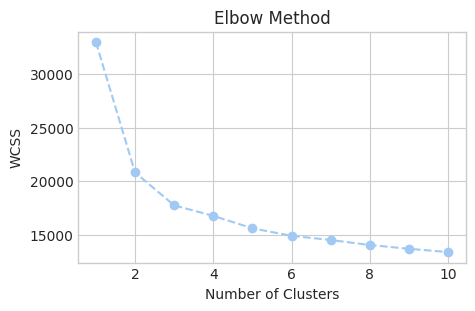

In [ ]:
# draw elbow plot
plt.figure(figsize=(5, 3))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# Recommendation: Use K = 3 and K = 4

### 3.2. Silhouette Score Method

In [ ]:
silhouette_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {i}: Silhouette Score = {score:.3f}")

K = 2: Silhouette Score = 0.320
K = 3: Silhouette Score = 0.244
K = 4: Silhouette Score = 0.184
K = 5: Silhouette Score = 0.143
K = 6: Silhouette Score = 0.142
K = 7: Silhouette Score = 0.125
K = 8: Silhouette Score = 0.117
K = 9: Silhouette Score = 0.105
K = 10: Silhouette Score = 0.108


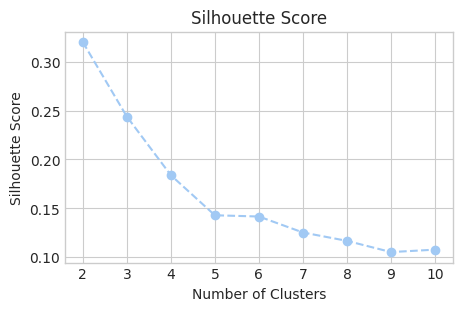

In [ ]:
# draw sihouette plot
plt.figure(figsize=(5, 3))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
# --> Silhouette score peaks at K=2 (0.320) and decreases steadily as K increases, with no clear peak at K=4.
# Statistically, a lower K gives better-separated clusters. K=2 and K=3 are profiled below alongside K=4
# to check what each split actually represents, before deciding which K is most useful for the business.

## 4. Fit models

### 4.1. With K = 2

In [ ]:
kmeans_2 = KMeans(n_clusters=2, random_state=0)

In [ ]:
df['Cluster_2'] = kmeans_2.fit_predict(X_scaled)
print(df['Cluster_2'].value_counts().sort_index())

In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

In [ ]:
# draw plot with K = 2
plt.figure(figsize=(5, 3))
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], 
                     c=df['Cluster_2'], cmap='viridis', 
                     alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster_2')
plt.title('Customer Segments (K=2)')
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.show()

### 4.2. With K = 3

In [ ]:
kmeans_3 = KMeans(n_clusters=3, random_state=0)

In [ ]:
df['Cluster_3'] = kmeans_3.fit_predict(X_scaled)
print(df['Cluster_3'].value_counts().sort_index())

Cluster_3
0    722
1    890
2    588
Name: count, dtype: int64


In [ ]:
pca_3 = PCA(n_components=2)
X_pca_3 = pca_3.fit_transform(X_scaled)

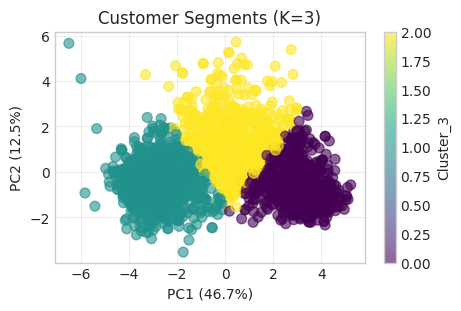

In [ ]:
# draw plot with K = 3
plt.figure(figsize=(5, 3))
scatter = plt.scatter(X_pca_3[:, 0], X_pca_3[:, 1], 
                     c=df['Cluster_3'], cmap='viridis', 
                     alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster_3')
plt.title('Customer Segments (K=3)')
plt.xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.show()

### 4.3. With K = 4

In [ ]:
kmeans_4 = KMeans(n_clusters=4, random_state=0)

In [ ]:
df['Cluster_4'] = kmeans_4.fit_predict(X_scaled)
print(df['Cluster_4'].value_counts().sort_index())

Cluster_4
0    425
1    837
2    462
3    476
Name: count, dtype: int64


In [ ]:
pca_4 = PCA(n_components=2)
X_pca_4 = pca_4.fit_transform(X_scaled)

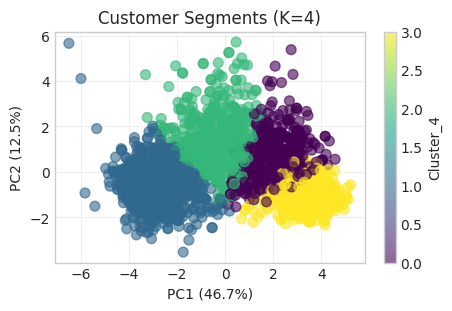

In [ ]:
# draw plot with K = 4
plt.figure(figsize=(5, 3))
scatter = plt.scatter(X_pca_4[:, 0], X_pca_4[:, 1], 
                     c=df['Cluster_4'], cmap='viridis', 
                     alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster_4')
plt.title('Customer Segments (K=4)')
plt.xlabel(f'PC1 ({pca_4.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_4.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# create function to profile clusters
def profile_clusters(df, k):
    print(f"\n{'='*60}")
    print(f"PROFILING K = {k}")
    print(f"{'='*60}")
    
    for cluster in range(k):
        cluster_data = df[df[f'Cluster_{k}'] == cluster]
        size = len(cluster_data)
        pct = size / len(df) * 100
        
        print(f"\nCluster {cluster} (n={size}, {pct:.1f}%)")
        print(f"{'─'*50}")
        
        # Demographics & Recency
        print(f"Income: {cluster_data['Income'].mean():>8.0f}")
        print(f"Recency: {cluster_data['Recency'].mean():>8.1f} days")
        
        # Education
        print(f"\nEducation:")
        edu_dist = cluster_data['Education'].value_counts(normalize=True) * 100
        for edu, pct_edu in edu_dist.head(3).items():
            print(f"    {edu:12s}: {pct_edu:>5.1f}%")

        # Children
        total_children = cluster_data['Kidhome'] + cluster_data['Teenhome']
        has_children_pct = (total_children > 0).mean() * 100
        print(f"\nChildren:")
        print(f"  Has children:   {has_children_pct:>8.1f}%")
        print(f"  Avg children:   {total_children.mean():>8.2f}")
        
        # Spending
        print(f"\nSpending:")
        print(f"  Wines:         {cluster_data['MntWines'].mean():>8.0f}")
        print(f"  Meat:          {cluster_data['MntMeatProducts'].mean():>8.0f}")
        print(f"  Fish:          {cluster_data['MntFishProducts'].mean():>8.0f}")
        print(f"  Sweet:         {cluster_data['MntSweetProducts'].mean():>8.0f}")
        print(f"  Fruits:        {cluster_data['MntFruits'].mean():>8.0f}")
        print(f"  Gold:          {cluster_data['MntGoldProds'].mean():>8.0f}")
        print(f"  Total:         {cluster_data[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1).mean():>8.0f}")
        
        # Channel behavior
        print(f"\nChannel:")
        print(f"  Web purchases: {cluster_data['NumWebPurchases'].mean():>8.1f}")
        print(f"  Catalog:       {cluster_data['NumCatalogPurchases'].mean():>8.1f}")
        print(f"  Store:         {cluster_data['NumStorePurchases'].mean():>8.1f}")
        print(f"  Deals:         {cluster_data['NumDealsPurchases'].mean():>8.1f}")
        print(f"  Web visits:    {cluster_data['NumWebVisitsMonth'].mean():>8.1f}")

## 5. Profile Clusters

### 5.1. Profile Clusters with K = 2

In [ ]:
profile_clusters(df, 2)

### 5.2. Profile Clusters with K = 3

In [ ]:
profile_clusters(df, 3)


PROFILING K = 3

Cluster 0 (n=722, 32.8%)
──────────────────────────────────────────────────
Income:    73035
Recency:     49.6 days

Education:
    Graduation  :  56.1%
    PhD         :  20.6%
    Master      :  14.3%

Children:
  Has children:       33.1%
  Avg children:       0.34

Spending:
  Wines:              579
  Meat:               392
  Fish:                90
  Sweet:               65
  Fruits:              63
  Gold:                74
  Total:             1263

Channel:
  Web purchases:      5.3
  Catalog:            5.5
  Store:              8.5
  Deals:              1.5
  Web visits:         3.1

Cluster 1 (n=890, 40.5%)
──────────────────────────────────────────────────
Income:    33387
Recency:     48.7 days

Education:
    Graduation  :  48.3%
    PhD         :  19.2%
    Master      :  16.0%

Children:
  Has children:       88.1%
  Avg children:       1.24

Spending:
  Wines:               29
  Meat:                16
  Fish:                 5
  Sweet:             

### 5.3. Profile Clusters with K = 4

In [ ]:
profile_clusters(df, 4)


PROFILING K = 4

Cluster 0 (n=425, 19.3%)
──────────────────────────────────────────────────
Income:    63388
Recency:     49.5 days

Education:
    Graduation  :  55.8%
    PhD         :  20.5%
    Master      :  11.8%

Children:
  Has children:       85.9%
  Avg children:       0.96

Spending:
  Wines:              509
  Meat:               210
  Fish:                64
  Sweet:               49
  Fruits:              48
  Gold:                71
  Total:              951

Channel:
  Web purchases:      6.6
  Catalog:            3.8
  Store:              8.9
  Deals:              2.9
  Web visits:         5.1

Cluster 1 (n=837, 38.0%)
──────────────────────────────────────────────────
Income:    32850
Recency:     48.9 days

Education:
    Graduation  :  49.2%
    PhD         :  18.5%
    Master      :  14.8%

Children:
  Has children:       87.8%
  Avg children:       1.23

Spending:
  Wines:               24
  Meat:                15
  Fish:                 5
  Sweet:             